In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>""
"""))

# 1. tensorflow v2.xx에서 v1사용하기

In [2]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior() # v2를 비활성화하고 v1활성화
import numpy as np
import pandas as pd

Instructions for updating:
non-resource variables are not supported in the long term


## Tensorflow
- 데이터 흐름 그래프(tensor객체의 흐름)
- 이 그래프는 node(상수, 변수, 연산)와 edge로 구성
- sess = tf.Session()으로 실행
- sess.run()을 통해 값을 확인

In [3]:
# tensor = data(상수, 변수)와 연산
node1= tf.constant('Hello, Tensorflow')
sess = tf.Session()
print(sess.run(node1))

b'Hello, Tensorflow'


In [4]:
# 간단한 연산 tensor 그래프
node1 = tf.constant(10, dtype=tf.float16)
node2 = tf.constant(20, dtype=tf.float16)
node3 = tf.add(node1, node2)
sess = tf.Session()
print(sess.run([node1, node2, node3]))

[10.0, 20.0, 30.0]


In [5]:
# 타입 변경
node1 = tf.constant(np.array([1,2,3]), dtype=tf.int16)
node2 = tf.cast(node1, dtype=tf.float32)
sess = tf.Session()
sess.run([node1, node2])

[array([1, 2, 3], dtype=int16), array([1., 2., 3.], dtype=float32)]

In [6]:
# 평균값 계산 : tf.reduce_mean()
data = np.array([1., 2., 3.])
tensor = tf.reduce_mean(data)
sess = tf.Session()
sess.run(tensor)

2.0

In [7]:
# 랜덤값을 갖는 tensor
a = tf.random_normal([1]) # 평균0, 표준편차가 1인 난수 실수 1개(정규분포이루는난수)
b = tf.random_normal([1])
sess = tf.Session()
sess.run([a, b])

[array([1.956867], dtype=float32), array([0.35506976], dtype=float32)]

In [8]:
w = tf.Variable(tf.random.normal([1]))
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # w변수의 난수 초기화
sess.run(w)

array([-1.3001696], dtype=float32)

# 2. tensorflow v1을 이용한 linear regression을 구현
## 2.1 독립변수 x가 1개, 타겟변수 y가 1개

In [12]:
x = np.array([1,2,3])
y = np.array([2,3,4])
# weight와 bias(처음엔 랜덤값으로 셋팅, 학습과정에서 변경)
W = tf.Variable(tf.random.normal([1]), name='weight')
b = tf.Variable(tf.random.normal([1]), name='bias')
# Hypothesis : 예측값
H = W*x + b
#cost function(손실함수 = mse;최소제곱법)
cost = tf.reduce_mean(tf.square(H-y)) #H-y제곱평균
'''
학습목적 : cost가 최소가 되는 w, b를 찾아내는 것
cost는 2차함수이므로 곡선그래프. 곡선위 미분값이 줄어드는 방향으로 학습(경사하강)
=> GradientDescentOptimizer
'''
optimizer = tf.train.GradientDescentOptimizer(learning_rate=0.01)
train = optimizer.minimize(cost)
#Session 생성
#W, b변수 노드에 초기화
sess.run(tf.global_variables_initializer())
#5000번 학습(v2에서는 fit함수)
for step in range(5001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b])
    if step%200 == 0:
        print("{}번째 cost:{}, W:{}, b:{}".format(step,
                                               cost_val,
                                               W_val,
                                               b_val))

0번째 cost:13.386876106262207, W:[0.51068306], b:[-1.2631066]
200번째 cost:0.16204865276813507, W:[1.466416], b:[-0.06027298]
400번째 cost:0.061878178268671036, W:[1.288217], b:[0.34481534]
600번째 cost:0.02362808771431446, W:[1.1781003], b:[0.5951358]
800번째 cost:0.009022368118166924, W:[1.1100553], b:[0.74981844]
1000번째 cost:0.0034451698884367943, W:[1.0680073], b:[0.84540325]
1200번째 cost:0.00131553306709975, W:[1.0420244], b:[0.90446866]
1400번째 cost:0.0005023376434110105, W:[1.0259686], b:[0.9409674]
1600번째 cost:0.0001918124035000801, W:[1.0160469], b:[0.9635217]
1800번째 cost:7.32445769244805e-05, W:[1.0099162], b:[0.9774584]
2000번째 cost:2.7968788344878703e-05, W:[1.0061276], b:[0.98607063]
2200번째 cost:1.0680002560548019e-05, W:[1.0037864], b:[0.99139243]
2400번째 cost:4.078411166119622e-06, W:[1.00234], b:[0.9946809]
2600번째 cost:1.5580102399326279e-06, W:[1.0014464], b:[0.99671245]
2800번째 cost:5.954740913693968e-07, W:[1.0008943], b:[0.9979676]
3000번째 cost:2.2780226061058784e-07, W:[1.0005533]

In [ ]:
# 최종적으로 나온 회귀식 : H = W*x + b
sess.run([W, b])

In [ ]:
W_, b_ = sess.run([W, b])
W_, b_[0]

In [ ]:
def predict(int_x):
    return W_[0]*x + b_[0]

In [ ]:
input_x = int(input('입력값은 ?'))
print('예측값은 ', predict(input_x))

## 2.2 predict를 위한 placeholder이용
- placeholder : 텐서플로우 외부에서 데이터를 입력받는 노드

In [10]:
# x = np.array([1,2,3])
x = tf.placeholder(tf.float16)
H = 1*x + 1
sess = tf.Session()
sess.run(H, feed_dict={x:5})
sess.run(H, feed_dict={x:np.array([1,2,3])})

array([2., 3., 4.], dtype=float16)

In [ ]:
# H = 2x+3
x_data = np.array([1,2,3,5,8])
y_data = np.array([3,5,7,11,17])
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
#W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
#Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
#경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate = 0.01).minimize(cost)
#Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) #W, b초기화
#5000번 학습
for step in range(5001):
    _, cost_val, W_val, b_val, sess.run([train, cost, W, b], 
                                         feed_dict={x:x_data,
                                                    y:y_data})
    if step%200 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

In [ ]:
sess.run(H, feed_dict={x:5})

In [ ]:
sess.run(H, feed_dict={x:np.array([5,6,7])})

## 2.3 scale이 다른 데이터의 linear regression 구현(scale조정X)

In [11]:
# H = 2x+3
x_data = np.array([1,2,5,8,10])
y_data = np.array([3,15,68,80,95])
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
#W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
#Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
#경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate = 0.01).minimize(cost)
#Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) #W, b초기화
#3000번 학습
for step in range(3001):
    _, cost_val, W_val, b_val, sess.run([train, cost, W, b], 
                                         feed_dict={x:x_data,
                                                    y:y_data})
    if step%200 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

NameError: name 'cost_val' is not defined

In [ ]:
# cost값이 멈춤 : local 최소값

## 2.4 scale이 다른 데이터의 linear regression을 구현(scale조정O)
### scale을 맞추기 : 모든 데이터를 일정 범위내로 조정
- normalization(정규화)
                      X - Xmin
    normalization =_________________
                     Xmax - Xmin
         * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.MinMaxScaler이용)
- standardization(표준화)
                      X - Xmean(평균)
    normalization =_________________
                      Xstd(표준편차)
         * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.StandardScaler이용)

In [ ]:
#라이브러리를 쓰지 않고 정규화
x_data = np.array([1,2,5,8,10])
y_data = np.array([3,15,68,80,95])
scaled_x_data = (x_data - x_data.min())/(x_data.max()-x_data.min())
scaled_y_data = (y_data - y_data.min())/(y_data.max()-y_data.min())
print(scaled_x_data)
print(scaled_y_data)

In [14]:
# 라이브러리를 쓰고 정규화 (MinMaxScaler이용)
x_data = np.array([1,2,5,8,10]).reshape(-1, 1)
y_data = np.array([3,15,68,80,95]).reshape(-1, 1)
np.column_stack([x_data, y_data])
from sklearn.preprocessing import MinMaxScaler
scaler_x = MinMaxScaler() # x_data를 정규화시킬 객체
# scaler_x.fir(x_data)
# scaled_x_data = scaler_x.transform(x_data)
scaled_x_data = scaler_x.fit_transform(x_data)
scaler_y = MinMaxScaler() # y_data를 정규화시킬 객체
scaled_y_data = scaler_y.fit_transform(y_data)
np.column_stack([x_data, y_data, scaled_x_data, scaled_y_data])

array([[ 1.        ,  3.        ,  0.        ,  0.        ],
       [ 2.        , 15.        ,  0.11111111,  0.13043478],
       [ 5.        , 68.        ,  0.44444444,  0.70652174],
       [ 8.        , 80.        ,  0.77777778,  0.83695652],
       [10.        , 95.        ,  1.        ,  1.        ]])

In [15]:
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
#W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
#Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
#경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate = 0.01).minimize(cost)
#Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) #W, b초기화
#3000번 학습
for step in range(9001):
    _, cost_val, W_val, b_val, sess.run([train, cost, W, b], 
                                         feed_dict={x:scaled_x_data,
                                                    y:scaled_y_data})
    if step%200 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
200째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
400째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
600째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
800째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1000째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1200째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1400째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1600째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1800째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2000째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2200째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2400째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2600째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2800째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
3000째 : cost:5.328478283606053e-

In [16]:
#예측 : 모델에 scale조정된 값으로 예측 =>scale 조정된 y값
scaled_input = scaler_x.transform(np.array([[2],
                                           [3]]))
print('모델 예측을 위한 입력 :',scaled_input, sep='\n')
scaled_output = sess.run(H, feed_dict={x:scaled_input})
print('모델 예측 결과 :',scaled_output, sep='\n')
print('결과 :', scaler_y.inverse_transform(scaled_output), sep='\n')

모델 예측을 위한 입력 :
[[0.11111111]
 [0.22222222]]
모델 예측 결과 :
[[0.17643476]
 [0.28841853]]
결과 :
[[19.231998]
 [29.534504]]


In [17]:
# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict={x:scaled_x_data})
y_hat = scaler_y.inverse_transform(scaled_y_hat)

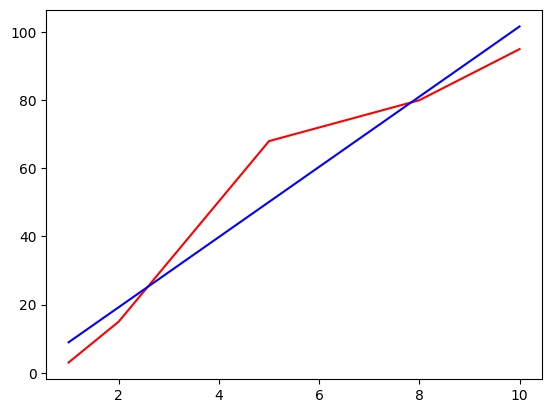

In [18]:
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')

In [24]:
# 라이브러리를 쓰고 표준화 (StandardScaler이용)
x_data = np.array([1,2,5,8,10]).reshape(-1, 1)
y_data = np.array([3,15,68,80,95]).reshape(-1, 1)
from sklearn.preprocessing import StandardScaler
scaler_x = StandardScaler() # x_data를 표준화할 객체
scaler_y = StandardScaler() # y_data를 표준화할 객체
scaled_x_data = scaler_x.fit_transform(x_data)
scaled_y_data = scaler_y.fit_transform(y_data)
print(np.column_stack([x_data, y_data]))
print(np.column_stack([scaled_x_data, scaled_y_data]))

[[ 1  3]
 [ 2 15]
 [ 5 68]
 [ 8 80]
 [10 95]]
[[-1.22474487 -1.34819316]
 [-0.93313895 -1.01936556]
 [-0.05832118  0.43295634]
 [ 0.81649658  0.76178394]
 [ 1.39970842  1.17281844]]


In [25]:
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
#W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
#Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
#경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate = 0.01).minimize(cost)
#Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) #W, b초기화
#3000번 학습
for step in range(9001):
    _, cost_val, W_val, b_val, sess.run([train, cost, W, b], 
                                         feed_dict={x:scaled_x_data,
                                                    y:scaled_y_data})
    if step%200 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
200째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
400째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
600째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
800째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1000째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1200째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1400째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1600째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1800째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2000째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2200째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2400째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2600째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2800째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
3000째 : cost:5.328478283606053e-

In [26]:
# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict={x:scaled_x_data})
y_hat = scaler_y.inverse_transform(scaled_y_hat)

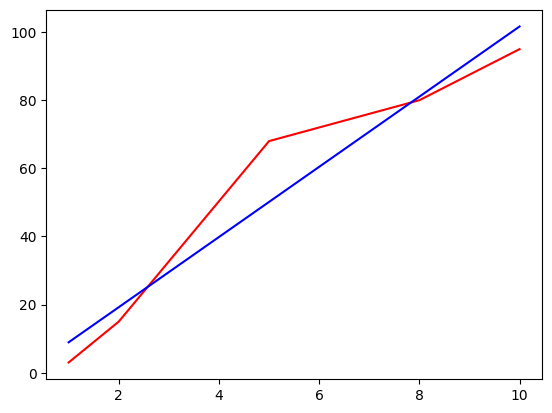

In [27]:
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')